# Vehicles.csv — Exploratory Data Analysis (DuckDB-first)

Dataset: **Craigslist Cars & Trucks (USA)**  
File: `vehicles.csv` (~426,881 rows; wide schema; heavy text columns like `description`)  

**Design principle:** Use DuckDB for scanning and aggregation. Only pull small aggregated result sets into pandas for charts.

![ETL Diagram](vehicles_lakehouse_etl_diagram.png)

---

## What you will do

1) Load `vehicles.csv` into a **Bronze view** (raw)  
2) Inspect schema + missingness + basic distributions  
3) Validate key columns (price, year, odometer, posting_date)  
4) Produce EDA charts from aggregated queries  


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("vehicles.csv")   # Put vehicles.csv in the same folder as this notebook (or change this path)
DB_PATH = Path("vehicles_eda.duckdb")

con = duckdb.connect(str(DB_PATH))
print("DuckDB:", duckdb.__version__)
print("Data path:", DATA_PATH.resolve())


DuckDB: 1.4.4
Data path: /Users/max/mp/work_in_jupyter/vehicles.csv


## 1) Bronze view: read_csv_auto (raw)

In [2]:
con.execute("""
DROP VIEW IF EXISTS bronze_vehicles;

CREATE VIEW bronze_vehicles AS
SELECT *
FROM read_csv_auto(
  'vehicles.csv',
  header=true,
  sample_size=50000,
  ignore_errors=true
);
""")

con.execute("SELECT COUNT(*) AS rows FROM bronze_vehicles;").df()


,rows
0,426880


## 2) Schema discovery

In [3]:
con.execute("DESCRIBE bronze_vehicles").df()

,column_name,column_type,null,key,default,extra
0,id,BIGINT,YES,None,None,None
1,url,VARCHAR,YES,None,None,None
2,region,VARCHAR,YES,None,None,None
3,region_url,VARCHAR,YES,None,None,None
4,price,BIGINT,YES,None,None,None
5,year,BIGINT,YES,None,None,None
6,manufacturer,VARCHAR,YES,None,None,None
7,model,VARCHAR,YES,None,None,None
8,condition,VARCHAR,YES,None,None,None
9,cylinders,VARCHAR,YES,None,None,None


## 3) Column completeness (missingness)

In [4]:
cols = [
  'price','year','manufacturer','model','condition','cylinders','fuel',
  'odometer','title_status','transmission','drive','size','type','paint_color',
  'state','lat','long','posting_date'
]

missing_sql = "SELECT\n" + ",\n".join([
    f"  SUM(CASE WHEN {c} IS NULL OR CAST({c} AS VARCHAR)='' THEN 1 ELSE 0 END) AS missing_{c}"
    for c in cols
]) + "\nFROM bronze_vehicles;"

miss = con.execute(missing_sql).df().T.reset_index()
miss.columns = ["metric","missing_count"]
miss["column"] = miss["metric"].str.replace("missing_","", regex=False)
miss = miss[["column","missing_count"]].sort_values("missing_count", ascending=False)
miss


,column,missing_count
11,size,306361.0
5,cylinders,177678.0
4,condition,174104.0
10,drive,130567.0
13,paint_color,130203.0
12,type,92858.0
2,manufacturer,17646.0
8,title_status,8242.0
15,lat,6549.0
16,long,6549.0


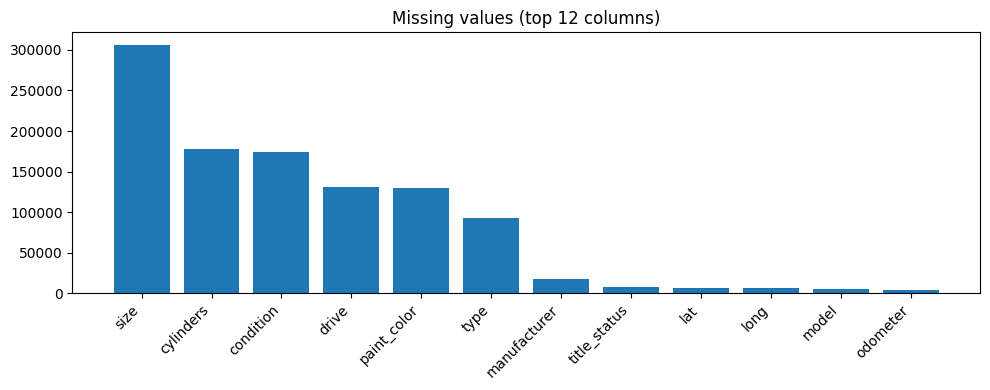

In [5]:
top = miss.head(12)
plt.figure(figsize=(10,4))
plt.bar(top["column"], top["missing_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Missing values (top 12 columns)")
plt.tight_layout()
plt.show()


## 4) Price distribution (robust bins)

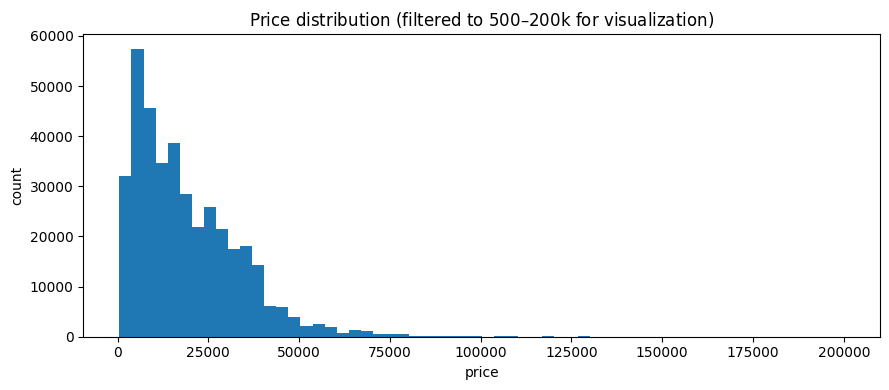

In [6]:
df = con.execute("""
SELECT price
FROM bronze_vehicles
WHERE price IS NOT NULL AND price BETWEEN 500 AND 200000
""").df()

plt.figure(figsize=(9,4))
plt.hist(df["price"], bins=60)
plt.title("Price distribution (filtered to $500–$200k for visualization)")
plt.xlabel("price"); plt.ylabel("count")
plt.tight_layout()
plt.show()


## 5) Posting date coverage

In [8]:
df = con.execute("""
SELECT
  posting_date::DATE AS post_date
FROM bronze_vehicles
WHERE posting_date IS NOT NULL
""").df()

df["post_date"].describe()


count                        426812
mean     2021-04-23 05:57:19.472180
min             2021-04-04 00:00:00
25%             2021-04-17 00:00:00
50%             2021-04-25 00:00:00
75%             2021-05-01 00:00:00
max             2021-05-04 00:00:00
Name: post_date, dtype: object

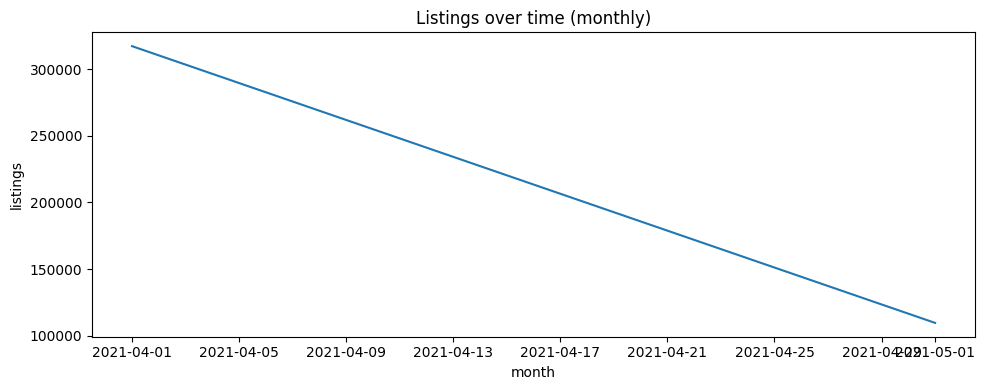

In [10]:
dfm = con.execute("""
WITH d AS (
  SELECT posting_date::DATE AS post_date
  FROM bronze_vehicles
  WHERE posting_date IS NOT NULL
)
SELECT
  date_trunc('month', post_date) AS month,
  COUNT(*) AS listings
FROM d
GROUP BY 1
ORDER BY 1;
""").df()

plt.figure(figsize=(10,4))
plt.plot(dfm["month"], dfm["listings"])
plt.title("Listings over time (monthly)")
plt.xlabel("month")
plt.ylabel("listings")
plt.tight_layout()
plt.show()

## 6) Top states by listing count

In [11]:
dft = con.execute("""
SELECT state, COUNT(*) AS listings
FROM bronze_vehicles
WHERE state IS NOT NULL AND state != ''
GROUP BY state
ORDER BY listings DESC
LIMIT 20;
""").df()

dft


,state,listings
0,ca,50614
1,fl,28511
2,tx,22945
3,ny,19386
4,oh,17696
5,or,17104
6,mi,16900
7,nc,15277
8,wa,13861
9,pa,13753


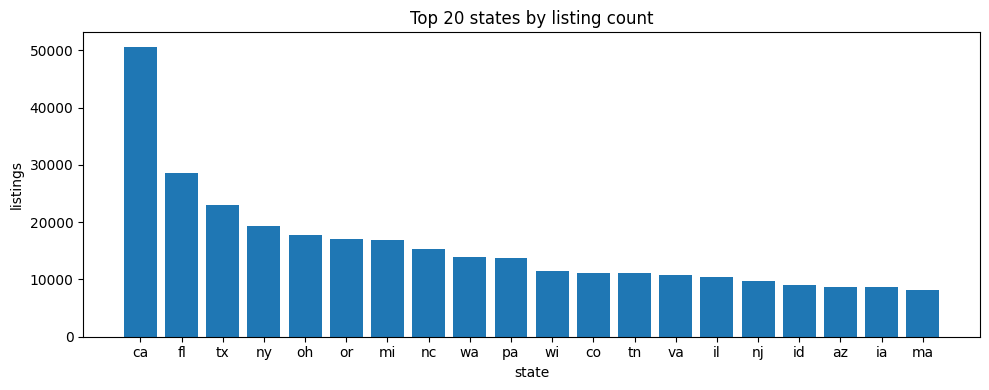

In [12]:
plt.figure(figsize=(10,4))
plt.bar(dft["state"], dft["listings"])
plt.title("Top 20 states by listing count")
plt.xlabel("state"); plt.ylabel("listings")
plt.tight_layout()
plt.show()


## 7) Manufacturers: coverage + typical prices

In [13]:
dfmfg = con.execute("""
SELECT
  lower(trim(manufacturer)) AS manufacturer,
  COUNT(*) AS listings,
  median(price) AS median_price
FROM bronze_vehicles
WHERE manufacturer IS NOT NULL AND manufacturer != ''
  AND price IS NOT NULL AND price BETWEEN 500 AND 200000
GROUP BY 1
HAVING COUNT(*) >= 1000
ORDER BY listings DESC
LIMIT 20;
""").df()

dfmfg


,manufacturer,listings,median_price
0,ford,63862,17000.0
1,chevrolet,49588,16000.0
2,toyota,30929,13995.0
3,honda,19409,9250.0
4,nissan,16952,10500.5
5,jeep,16836,18900.0
6,ram,16172,29995.0
7,gmc,15220,24224.0
8,bmw,13311,18500.0
9,dodge,11717,12500.0


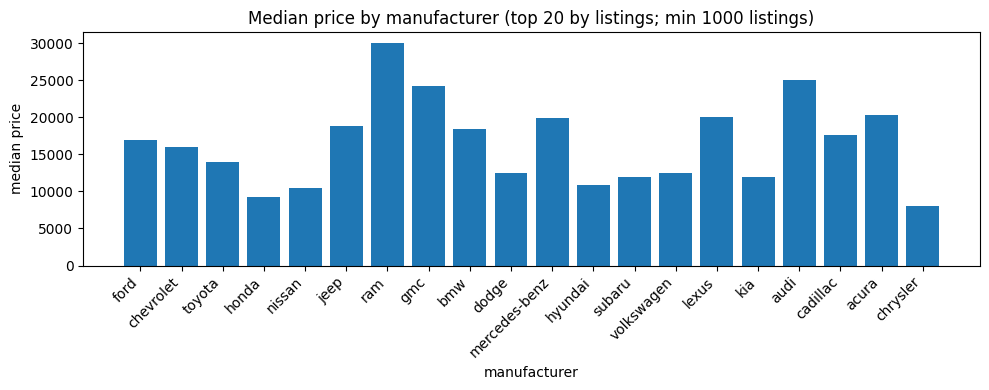

In [14]:
plt.figure(figsize=(10,4))
plt.bar(dfmfg["manufacturer"], dfmfg["median_price"])
plt.xticks(rotation=45, ha="right")
plt.title("Median price by manufacturer (top 20 by listings; min 1000 listings)")
plt.xlabel("manufacturer"); plt.ylabel("median price")
plt.tight_layout()
plt.show()
